# Data Science in Psychology and Neuroscience

## Class info:
* Week #11
* Day: March 31, 2026
* Time: 9:30—10:45 AM
* Location: Logan Hall 125
* <a href="https://forms.microsoft.com/r/26vAcJWrwH">Click here to submit your attendance for Week 11, Question 19!</a>
  
## Instructor info:
* Dr. Jeremy Hogeveen
* jhogeveen@unm.edu
* Logan Hall 281 (Office Hours By Appointment)
  
## Syllabus:
* <a href="https://www.dropbox.com/scl/fi/6fs6fi4kvkwtxn7j7x8ua/PSY450650_DSPN_Spring2026_Syllabus.pdf?rlkey=148e5t4ah8q2n1daclt7mp0h6&dl=0">Download here</a>

## Today's topic:
* Modeling our ketamine trial data, continued
1. Repeated-measures ANOVA
2. Three by three mixed ANOVA (the omnibus test)
3. When ANOVAs let you down...
4. Linear Mixed Models (LMMs).
    * Fit our first LMM using `lme4`.
 

# Section 1. Repeated-Measures ANOVA, continuation from last class

## 1.1 Are there differences between the pre, post, _and_ followup HAMD changes in the ketamine group.

In [1]:
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(rstatix))
suppressPackageStartupMessages(library(afex))
suppressPackageStartupMessages(library(emmeans))
suppressPackageStartupMessages(library(knitr))

df <- read_csv('../data/synth_ketamine_data.csv')


# Reorder the factor levels in your data frame
desired_order <- c("Pre", "Post", "Followup")
df$Time <- factor(df$Time, levels = desired_order)

head(df)

Rows: 180 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Drug, Time
dbl (3): Subject, Change, HAMD

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Subject,Drug,Change,Time,HAMD
<dbl>,<chr>,<dbl>,<fct>,<dbl>
1,Ketamine,10.89830,Pre,28.112875
1,Ketamine,10.89830,Post,17.214579
1,Ketamine,10.89830,Followup,15.227329
2,Ketamine,12.55569,Pre,22.305905
2,Ketamine,12.55569,Post,9.750214
2,Ketamine,12.55569,Followup,7.809342


Time,variable,n,mean,ci
<fct>,<fct>,<dbl>,<dbl>,<dbl>
Pre,HAMD,20,24.576,1.843
Post,HAMD,20,12.094,2.206
Followup,HAMD,20,12.509,2.331


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


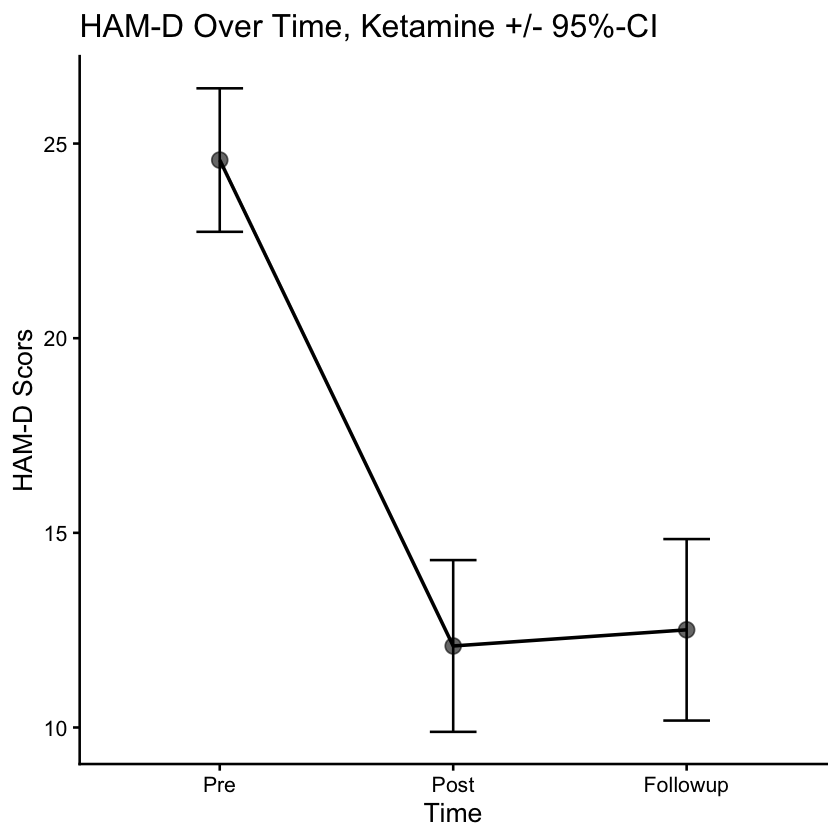

In [5]:
df_ketamine <- df %>%
    filter(Drug=="Ketamine")
# head(df_ketamine)

# descriptive stats
df_rm_plot <- df_ketamine %>%
    group_by(Time) %>%
    get_summary_stats(HAMD, type="mean_ci")
df_rm_plot

# visualizing the rmANOVA model for ketamine
p_rm_anova <- ggplot(df_rm_plot,aes(x = Time, y = mean, group = 1)) +
    geom_line(size=1) +
    geom_errorbar(aes(ymin = mean - ci, ymax = mean + ci), width = 0.2) +
    geom_point(size = 4, alpha=0.6) + 
    theme_classic(base_size = 16) + 
    ylab("HAM-D Scors") +
    ggtitle("HAM-D Over Time, Ketamine +/- 95%-CI")
p_rm_anova

In [11]:
# # basic anovas using afex
# model_object <- aov_ez(
#     id = "subject_id",
#     dv = "dependent_variable".
#     data = your_df,
#     between = c("between_factor"),
#     within = c("within_factor"))

# head(df_ketamine)

# Model
m_rm_anova <- aov_ez(
    id = "Subject",
    dv = "HAMD",
    data = df_ketamine,
    within = "Time"
)

summary(m_rm_anova)

# pulling estimated marginal means for pairwise comparisons
means_rm <- emmeans(m_rm_anova,pairwise ~ Time, adjust = "tukey")
# summary(means_rm)
kable(means_rm$emmeans, digits = 3, caption = "EMmeans from RM-ANOVA")
kable(means_rm$contrasts, digits = 3, caption = "Post-Hoc Tests from RM-ANOVA")


Univariate Type III Repeated-Measures ANOVA Assuming Sphericity

             Sum Sq num Df Error SS den Df F value    Pr(>F)    
(Intercept) 16123.8      1  1044.00     19  293.44 5.212e-13 ***
Time         2010.5      2   144.08     38  265.12 < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Mauchly Tests for Sphericity

     Test statistic    p-value
Time        0.39897 0.00025613


Greenhouse-Geisser and Huynh-Feldt Corrections
 for Departure from Sphericity

     GG eps Pr(>F[GG])    
Time 0.6246  3.197e-15 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

        HF eps  Pr(>F[HF])
Time 0.6474051 1.06747e-15



Table: EMmeans from RM-ANOVA

|Time     | emmean|    SE| df| lower.CL| upper.CL|
|:--------|------:|-----:|--:|--------:|--------:|
|Pre      | 24.576| 0.881| 19|   22.733|   26.419|
|Post     | 12.094| 1.054| 19|    9.888|   14.300|
|Followup | 12.509| 1.114| 19|   10.178|   14.840|



Table: Post-Hoc Tests from RM-ANOVA

|contrast        | estimate|    SE| df| t.ratio| p.value|
|:---------------|--------:|-----:|--:|-------:|-------:|
|Pre - Post      |   12.482| 0.545| 19|  22.884|   0.000|
|Pre - Followup  |   12.067| 0.815| 19|  14.802|   0.000|
|Post - Followup |   -0.415| 0.419| 19|  -0.991|   0.591|

* Modeling our ketamine trial data, continued
1. ~~Repeated-measures ANOVA~~
2. Three by three mixed ANOVA (the omnibus test)
3. When ANOVAs let you down...
4. Linear Mixed Models (LMMs).
    * Fit our first LMM using `lme4`.

# Section 2. The omnibus ANOVA

## 2.1 Running a `3 (time: pre, posttest, followup)` x `3 (drug: ketamine, amphetamine, placebo)` Mixed ANOVA
*  Are there differences in the long-term antidepressant effects of ketamine versus amphetamine versus placebo?
*  This represents the omnibus test for this design.
    *  AKA, what we'd actually run first if this was our study. Why?
        * Multiple comparisons issues:
            * At this point, we'd run i) a `paired t-test`, ii) an `independent t-test`, iii) a `one-way ANOVA`, and iv) a `rm-ANOVA`.
            * Family-Wise Error Rate (FWER): $FWER =  1 - (1 - \alpha)^n$.
                * $FWER = 1 - (1 - 0.95)^4$
                * $FWER = 0.1855$
                * False positive rate has ≈quadrupled.
        * Maximizes statistical power:
            * Using all subjects + data points to estimate error variance.
            * Higher error degrees of freedom in the ANOVA denominator, lower critical threshold for significance.
        * Capturing the critical `interaction term` (drug * time)
            * Does the trajectory of change depend on the drug? Only the interaction term in the omnibus model does that.

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Drug and Time.
ℹ Output is grouped by Drug.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Drug, Time))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


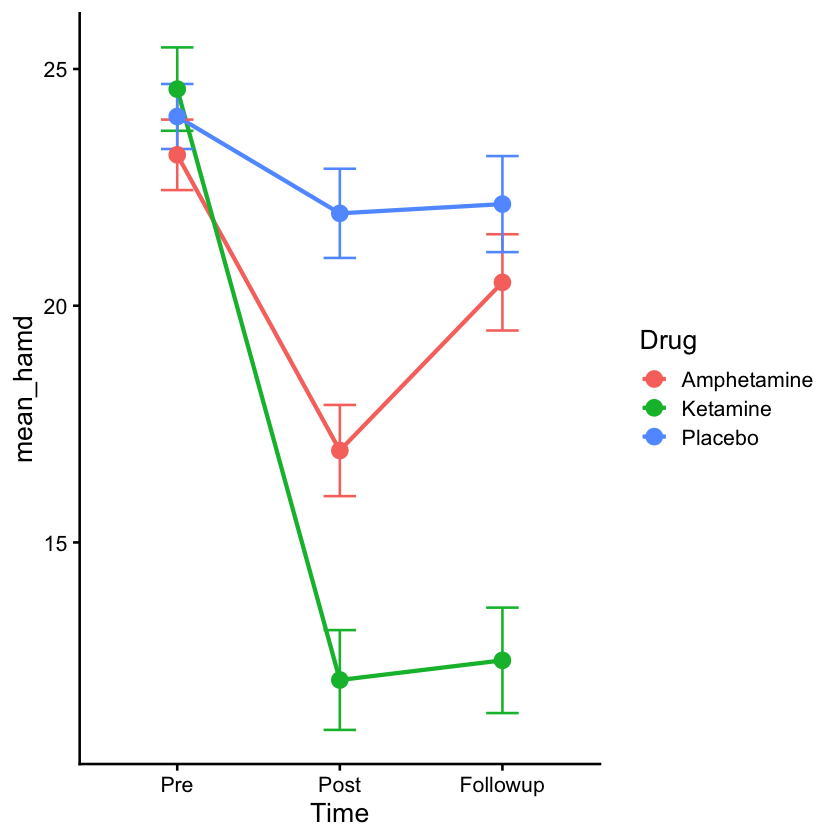

In [13]:
# visualize the effects
df_mixed_anova <- df %>%
    group_by(Drug, Time) %>%
    summarise(mean_hamd = mean(HAMD),
              se_hamd = sd(HAMD) / sqrt(n()))
# df_mixed_anova

# plotting the effects
p_mixed_anova <- ggplot(df_mixed_anova,aes(x = Time, y = mean_hamd, color = Drug, group = Drug)) +
    geom_line(size=1.2) +
    geom_errorbar(aes(ymin = mean_hamd - se_hamd, ymax = mean_hamd + se_hamd), width=0.2) +
    geom_point(size=4) +
    theme_classic(base_size=16)
p_mixed_anova

In [15]:
# Running the mixed mode
m_mixed_anova <- aov_ez(
    id = "Subject",
    dv = "HAMD",
    data = df,
    between = "Drug",
    within = "Time"
    )
summary(m_mixed_anova)

# running the EMmeans function
means_mixed <- emmeans(m_mixed_anova, pairwise ~ Drug | Time, adjust = "tukey")
kable(means_mixed$emmeans,digits=3, caption = "EMMeans from mixed ANOVA")
kable(means_mixed$contrasts,digits=3, caption = "PostHoc Tests from mixed ANOVA")

Converting to factor: Drug

Contrasts set to contr.sum for the following variables: Drug




Univariate Type III Repeated-Measures ANOVA Assuming Sphericity

            Sum Sq num Df Error SS den Df  F value    Pr(>F)    
(Intercept)  70326      1  2633.03     57 1522.428 < 2.2e-16 ***
Drug          1210      2  2633.03     57   13.100 2.084e-05 ***
Time          1611      2   418.71    114  219.263 < 2.2e-16 ***
Drug:Time      843      4   418.71    114   57.403 < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Mauchly Tests for Sphericity

          Test statistic    p-value
Time             0.59011 3.8568e-07
Drug:Time        0.59011 3.8568e-07


Greenhouse-Geisser and Huynh-Feldt Corrections
 for Departure from Sphericity

           GG eps Pr(>F[GG])    
Time      0.70928  < 2.2e-16 ***
Drug:Time 0.70928  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

             HF eps  Pr(>F[HF])
Time      0.7221494 1.82331e-29
Drug:Time 0.7221494 9.42384e-20



Table: EMMeans from mixed ANOVA

|Drug        |Time     | emmean|    SE| df| lower.CL| upper.CL|
|:-----------|:--------|------:|-----:|--:|--------:|--------:|
|Amphetamine |Pre      | 23.187| 0.775| 57|   21.636|   24.738|
|Ketamine    |Pre      | 24.576| 0.775| 57|   23.024|   26.127|
|Placebo     |Pre      | 23.997| 0.775| 57|   22.446|   25.549|
|Amphetamine |Post     | 16.941| 0.988| 57|   14.963|   18.919|
|Ketamine    |Post     | 12.094| 0.988| 57|   10.116|   14.072|
|Placebo     |Post     | 21.951| 0.988| 57|   19.974|   23.929|
|Amphetamine |Followup | 20.493| 1.049| 57|   18.392|   22.594|
|Ketamine    |Followup | 12.509| 1.049| 57|   10.408|   14.611|
|Placebo     |Followup | 22.147| 1.049| 57|   20.045|   24.248|



Table: PostHoc Tests from mixed ANOVA

|contrast               |Time     | estimate|    SE| df| t.ratio| p.value|
|:----------------------|:--------|--------:|-----:|--:|-------:|-------:|
|Amphetamine - Ketamine |Pre      |   -1.389| 1.096| 57|  -1.267|   0.419|
|Amphetamine - Placebo  |Pre      |   -0.810| 1.096| 57|  -0.739|   0.741|
|Ketamine - Placebo     |Pre      |    0.578| 1.096| 57|   0.528|   0.858|
|Amphetamine - Ketamine |Post     |    4.847| 1.397| 57|   3.470|   0.003|
|Amphetamine - Placebo  |Post     |   -5.010| 1.397| 57|  -3.587|   0.002|
|Ketamine - Placebo     |Post     |   -9.857| 1.397| 57|  -7.057|   0.000|
|Amphetamine - Ketamine |Followup |    7.984| 1.484| 57|   5.380|   0.000|
|Amphetamine - Placebo  |Followup |   -1.654| 1.484| 57|  -1.114|   0.509|
|Ketamine - Placebo     |Followup |   -9.637| 1.484| 57|  -6.494|   0.000|

* Modeling our ketamine trial data, continued
1. ~~Repeated-measures ANOVA~~
2. ~~Three by three mixed ANOVA (the omnibus test)~~
3. When ANOVAs let you down...
4. Linear Mixed Models (LMMs).
    * Fit our first LMM using `lme4`.

# Section 3. When ANOVAs let us down.
### 3.1 What if ≈25% of our subjects did not return at 6-month follow-up?

In [29]:
df_missing <- df %>%
    mutate( HAMD = ifelse(Time == "Followup" & runif(n()) < 0.25, NA, HAMD)
           )

# count how many NAs we have
sum(is.na(df_missing$HAMD))

# Run the mixed ANOVA with missingness
m_mixed_anova_wmissingness <- aov_ez(
    id = "Subject",
    dv = "HAMD",
    data = df_missing,
    between = "Drug",
    within = "Time"
    )
summary(m_mixed_anova_wmissingness)

[1] 24

Converting to factor: Drug

Warning message:
“Missing values for 24 ID(s), which were removed before analysis:
1, 3, 4, 7, 10, 13, 14, 15, 17, 18, ... [showing first 10 only]
Below the first few rows (in wide format) of the removed cases with missing data.
     Subject     Drug      Pre      Post Followup
# 1        1 Ketamine 28.11288 17.214579       NA
# 3        3 Ketamine 25.08939 11.343914       NA
# 4        4 Ketamine 25.89859  9.699377       NA
# 7        7 Ketamine 28.53457 15.527022       NA
# 10      10 Ketamine 23.81186  9.649223       NA
# 13      13 Ketamine 19.83342  5.962863       NA”
Contrasts set to contr.sum for the following variables: Drug




Univariate Type III Repeated-Measures ANOVA Assuming Sphericity

            Sum Sq num Df Error SS den Df  F value    Pr(>F)    
(Intercept)  43248      1  1764.00     33 809.0641 < 2.2e-16 ***
Drug           438      2  1764.00     33   4.0994    0.0257 *  
Time           958      2   256.27     66 123.3023 < 2.2e-16 ***
Drug:Time      450      4   256.27     66  28.9692 6.535e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Mauchly Tests for Sphericity

          Test statistic    p-value
Time              0.4966 1.3679e-05
Drug:Time         0.4966 1.3679e-05


Greenhouse-Geisser and Huynh-Feldt Corrections
 for Departure from Sphericity

           GG eps Pr(>F[GG])    
Time      0.66516  4.194e-16 ***
Drug:Time 0.66516  5.916e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

             HF eps   Pr(>F[HF])
Time      0.6825249 1.834359e-16
Drug:Time 0.6825249 3.681711e-10

## 3.2 Key scenarios when linear mixed models (LMMs) are superior to ANOVA
* Missing data.
* Unbalanced designs.
* Autocorrelated data.
    * Timeseries data.
    * Longitudinal data.
* Complex nested data structures.
    * e.g. Students within classrooms, patients within diagnostic categories, animals within a litter, etc.
* Continuous time.
* Strong violations of sphericity assumptions in rmANOVA.

### Modeling our ketamine trial data, continued
1. ~~Repeated-measures ANOVA~~
2. ~~Three by three mixed ANOVA (the omnibus test)~~
3. ~~When ANOVAs let you down...~~
4. Linear Mixed Models (LMMs).
    * Fit our first LMM using `lme4`.

# Section 4. Linear Mixed Models (LMMs)
* AKA mixed models, multilevel models, hierarchical models.
* LMMs don't rely on perfect, balanced matrices.
    * They look at all available data points.
    * If a subject has a Pre and Post score but no Followup, the LMM still uses their Pre and Post data to estimate the overall trajectories!
    * Model works by maximizing the likelihood of the model given _all_ the data we have.

## 4.1 But how?

* To understand how Linear Mixed Models handle this data, we need to split our variables into two distinct categories: `Fixed Effects` and `Random Effects`.
* Fixed Effects (`Drug` and `Time`): These are the experimental variables we actually care about testing and generalizing to the broader population. We want to know the *universal, average* effect of Ketamine versus Placebo over time. 
* Random Effects (`Subject`): This accounts for the idiosyncratic "noise" in our specific sample. We don't care about Subject #42's specific life story, but we *do* know that Subject #42 might naturally start with higher depression scores than Subject #12. Random effects allow us to mathematically control for this individual variation.

* The Syntax: `HAMD ~ Drug * Time + (1 | Subject)`
1. `Drug * Time` represents our ___Fixed Effects___. 
2. `(1 | Subject)` tells the model to add a ___Random Intercept___ for each person.

* In plain English: _"Calculate the overall, average effects of the Drug over Time, but allow every single subject to start at their own unique baseline level of depression."_

## 4.2 Running the LMM and Checking Assumptions
* Now that we understand the difference between fixed and random effects, let's fit our model and look at the residuals.
    * Just like with standard ANOVAs, we want to make sure our errors are normally distributed and roughly equal across our groups.

In [33]:
# load the necessary packages
suppressPackageStartupMessages(library(lme4))
suppressPackageStartupMessages(library(lmerTest))
suppressPackageStartupMessages(library(ggeffects))

# fit our linear mixed effects model
m_lmm <- lmer(HAMD ~ Drug * Time + (1 | Subject),df)

# print the omnibus table and detailed coefficients table
anova(m_lmm)
summary(m_lmm)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
Drug,96.2283,48.11415,2,57,13.09974,2.084469e-05
Time,1610.6686,805.33432,2,114,219.26340,8.500322e-40
Drug:Time,843.3469,210.83673,4,114,57.40321,1.904043e-26


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: HAMD ~ Drug * Time + (1 | Subject)
   Data: df

REML criterion at convergence: 879

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.84472 -0.57870  0.03284  0.55485  2.41740 

Random effects:
 Groups   Name        Variance Std.Dev.
 Subject  (Intercept) 14.174   3.765   
 Residual              3.673   1.916   
Number of obs: 180, groups:  Subject, 60

Fixed effects:
                          Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)                23.1870     0.9446  75.6140  24.546  < 2e-16 ***
DrugKetamine                1.3887     1.3359  75.6140   1.040    0.302    
DrugPlacebo                 0.8102     1.3359  75.6140   0.607    0.546    
TimePost                   -6.2459     0.6060 114.0000 -10.306  < 2e-16 ***
TimeFollowup               -2.6939     0.6060 114.0000  -4.445 2.05e-05 ***
DrugKetamine:TimePost      -6.2359     0.8571 114.0000  -7.2

In [34]:
df$Drug <- relevel(as.factor(df$Drug), ref = "Placebo")

# fir our lmm again, with the new drug factor
m_lmm2 <- lmer(HAMD ~ Drug * Time + (1 | Subject),df)

# print the omnibus table and detailed coefficients table
anova(m_lmm2)
summary(m_lmm2)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
Drug,96.2283,48.11415,2,57,13.09974,2.084469e-05
Time,1610.6685,805.33424,2,114,219.26338,8.500359e-40
Drug:Time,843.3469,210.83673,4,114,57.40321,1.904043e-26


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: HAMD ~ Drug * Time + (1 | Subject)
   Data: df

REML criterion at convergence: 879

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.84472 -0.57870  0.03284  0.55485  2.41740 

Random effects:
 Groups   Name        Variance Std.Dev.
 Subject  (Intercept) 14.174   3.765   
 Residual              3.673   1.916   
Number of obs: 180, groups:  Subject, 60

Fixed effects:
                             Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)                   23.9973     0.9446  75.6140  25.404  < 2e-16 ***
DrugAmphetamine               -0.8102     1.3359  75.6140  -0.607  0.54599    
DrugKetamine                   0.5785     1.3359  75.6140   0.433  0.66622    
TimePost                      -2.0460     0.6060 114.0000  -3.376  0.00101 ** 
TimeFollowup                  -1.8506     0.6060 114.0000  -3.054  0.00282 ** 
DrugAmphetamine:TimePost      -4.1999     

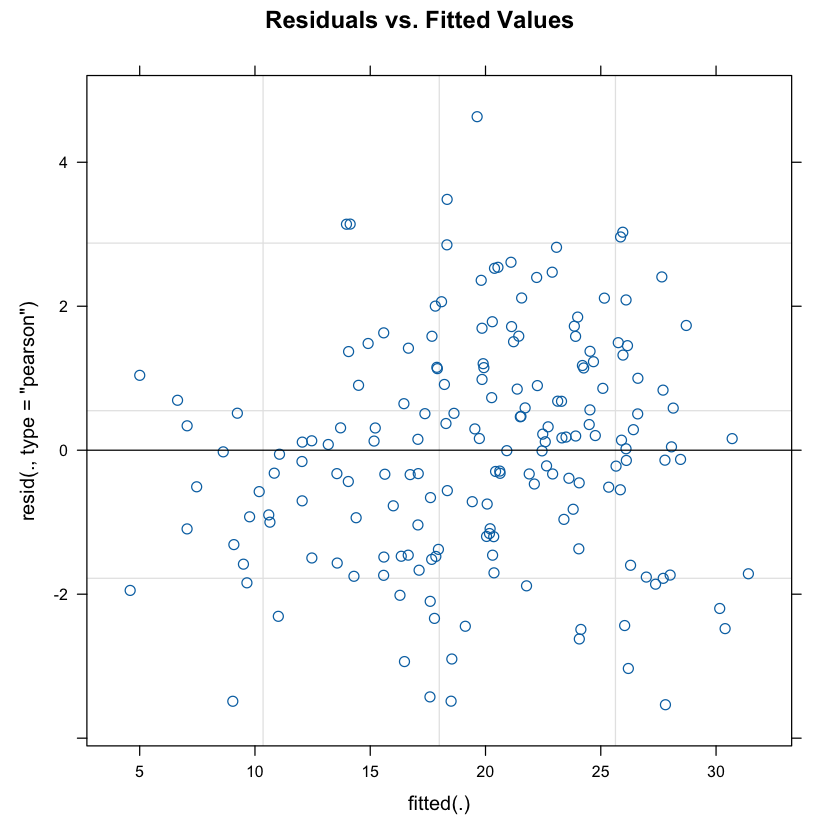

In [36]:
# check our residuals for homogeneity of variabnce
plot(m_lmm2,main = "Residuals vs. Fitted Values")

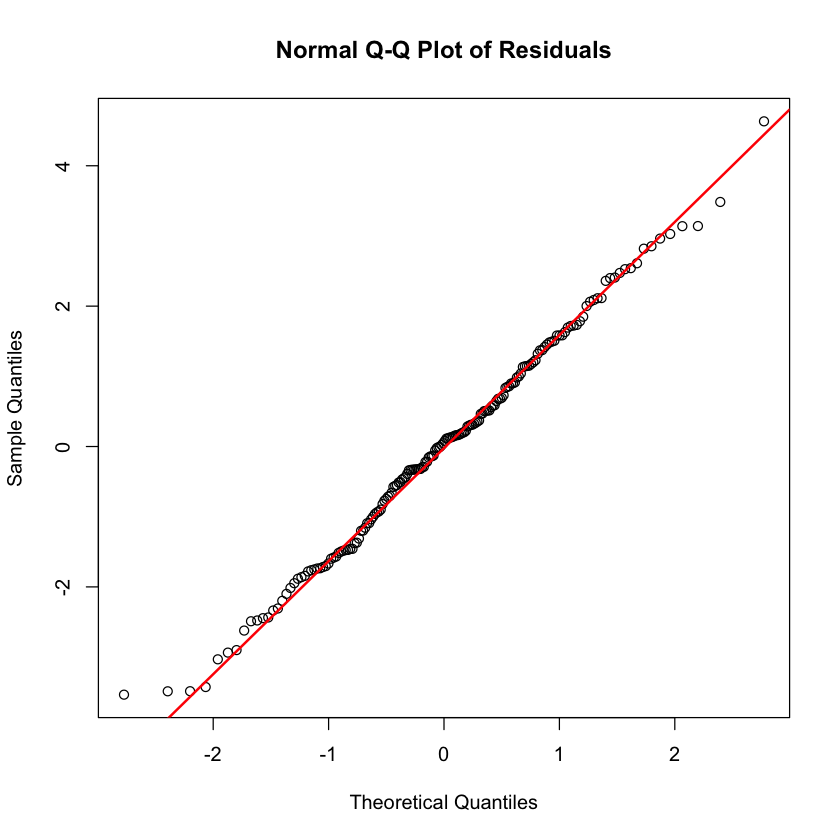

In [37]:
# QQ-Plotm (checks for normality of residuals)
qqnorm(resid(m_lmm2), main = "Normal Q-Q Plot of Residuals")
qqline(resid(m_lmm2), col = "red", lwd=2)

## 4.3 Visualizing the LMM interaction
* To plot our interaction, we need to extract the predicted values from our model. 
    * Here is the critical difference between plotting a standard `lm()` and an `lmer()` model: If we just ask the model for predictions, it will try to draw a unique line for every single subject based on their Random Intercept!
    * Since we want to plot the overall, universal effect of the drugs, we need to tell the `predict()` function to ignore the random subject variance and only calculate the ___Fixed Effects___. We do this using the argument `re.form = NA`.

## 4.4 The flexibility of LMMs
* LMMs can handle designs much more sophisticated than our simple `(1 | Subject)` random intercept.
* Two incredibly common extensions in clinical and neuroscience research are:
    * Nested Designs:
        * What if our sample included patients with two different underlying conditions (e.g., Major Depressive Disorder vs. Bipolar Depression)?
        * We can model this explicitly as a ___nested random intercept___
            * Changing our syntax to `(1 | Diagnosis/Subject)` tells the model: _"Subjects belong to specific Diagnostic groups; calculate an overarching baseline for MDD vs. BPD, and then calculate each individual Subject's baseline within their respective group."_
    * Random Slopes:
      * Our model assumes the drug worked at the exact same _rate_ for everyone (i.e., random intercepts, parallel slopes over Time).
      * In reality, Ketamine might drop depression scores incredibly fast for Subject 1, but very slowly for Subject 2, etc. 
      * We can add a ___Random Slope___ to explicitly model this variance
          * Changing our syntax to `(1 + Time | Subject)` tells the model: _"Give everyone their own starting baseline (intercept), AND allow everyone to have their own unique trajectory or rate of change (slope) over time."_
            
<img src="img/LMMs.png" width=600>
(<a href="https://peerj.com/articles/4794/">figure ref</a>)